# 06 - Meaningful Insights & Business Analysis

This notebook translates model results into actionable business insights.

## Objectives:
- Extract key findings from model
- Analyze business implications
- Identify success factors for movie revenue
- Provide recommendations
- Visualization of key insights

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/processed/movies_featured.csv')
df.head()

,budget,revenue,runtime,poster_brightness,poster_saturation,poster_dom_r,poster_dom_g,poster_dom_b,num_production_companies,num_production_countries,...,release_month,is_summer,is_holiday,is_weekend_month,movie_age,decade,num_keywords,has_keywords,in_collection,is_english
0,18.683045,19.610712,130,70.23,46.01,65.0,62.0,62.0,4,1,...,6,1,0,0,24,2000,20,1,0,1
1,18.627695,19.661371,105,157.19,130.06,96.0,119.0,136.0,3,2,...,11,0,1,0,24,2000,11,1,0,1
2,18.420681,19.490277,130,215.60,56.41,171.0,202.0,215.0,3,1,...,7,1,0,1,24,2000,25,1,0,1
3,18.132999,19.507016,104,87.53,54.47,78.0,78.0,76.0,4,1,...,7,1,0,1,24,2000,4,1,1,1
4,18.064006,19.740034,127,130.82,77.85,124.0,105.0,94.0,3,1,...,12,0,1,1,24,2000,13,1,0,1


In [59]:
df.columns.to_list()

['budget',
 'revenue',
 'runtime',
 'poster_brightness',
 'poster_saturation',
 'poster_dom_r',
 'poster_dom_g',
 'poster_dom_b',
 'num_production_companies',
 'num_production_countries',
 'budget_per_minute',
 'num_genres',
 'is_action',
 'is_animation',
 'is_comedy',
 'is_drama',
 'is_scifi',
 'num_cast',
 'has_cast',
 'num_directors',
 'release_year',
 'release_month',
 'is_summer',
 'is_holiday',
 'is_weekend_month',
 'movie_age',
 'decade',
 'num_keywords',
 'has_keywords',
 'in_collection',
 'is_english']

## Comparision revenue: Movies released in summer vs Movies release in other season

In [60]:
df['revenue_actual'] = np.exp(df['revenue'])
# Revenue by summer season
summer_revenue = df.groupby('is_summer').agg({
    'revenue_actual': 'sum'
}).reset_index()

# Rename columns for clarity
summer_revenue.columns = ['is_summer', 'total_revenue']
summer_revenue['season_label'] = summer_revenue['is_summer'].map({
    1: 'Release in summer',
    0: 'Release in other seasons'
})
summer_revenue['num_movies'] = df.groupby('is_summer').size().values
print("Revenue by release season:")
for idx, row in summer_revenue.iterrows():
    label = row['season_label']
    revenue = row['total_revenue'] / 1e9  # Convert to billions
    num = row['num_movies']
    avg = (row['total_revenue'] / num) / 1e6  # Average revenue in millions
    print(f"{label:30} | Total: ${revenue:,.2f}B | Number of movies: {num:,} | Average: ${avg:,.1f}M")

summer_revenue

Revenue by release season:
Release in other seasons       | Total: $410.35B | Number of movies: 8,902 | Average: $46.1M
Release in summer              | Total: $194.58B | Number of movies: 2,340 | Average: $83.2M


,is_summer,total_revenue,season_label,num_movies
0,0,4.103533e+11,Release in other seasons,8902
1,1,1.945788e+11,Release in summer,2340


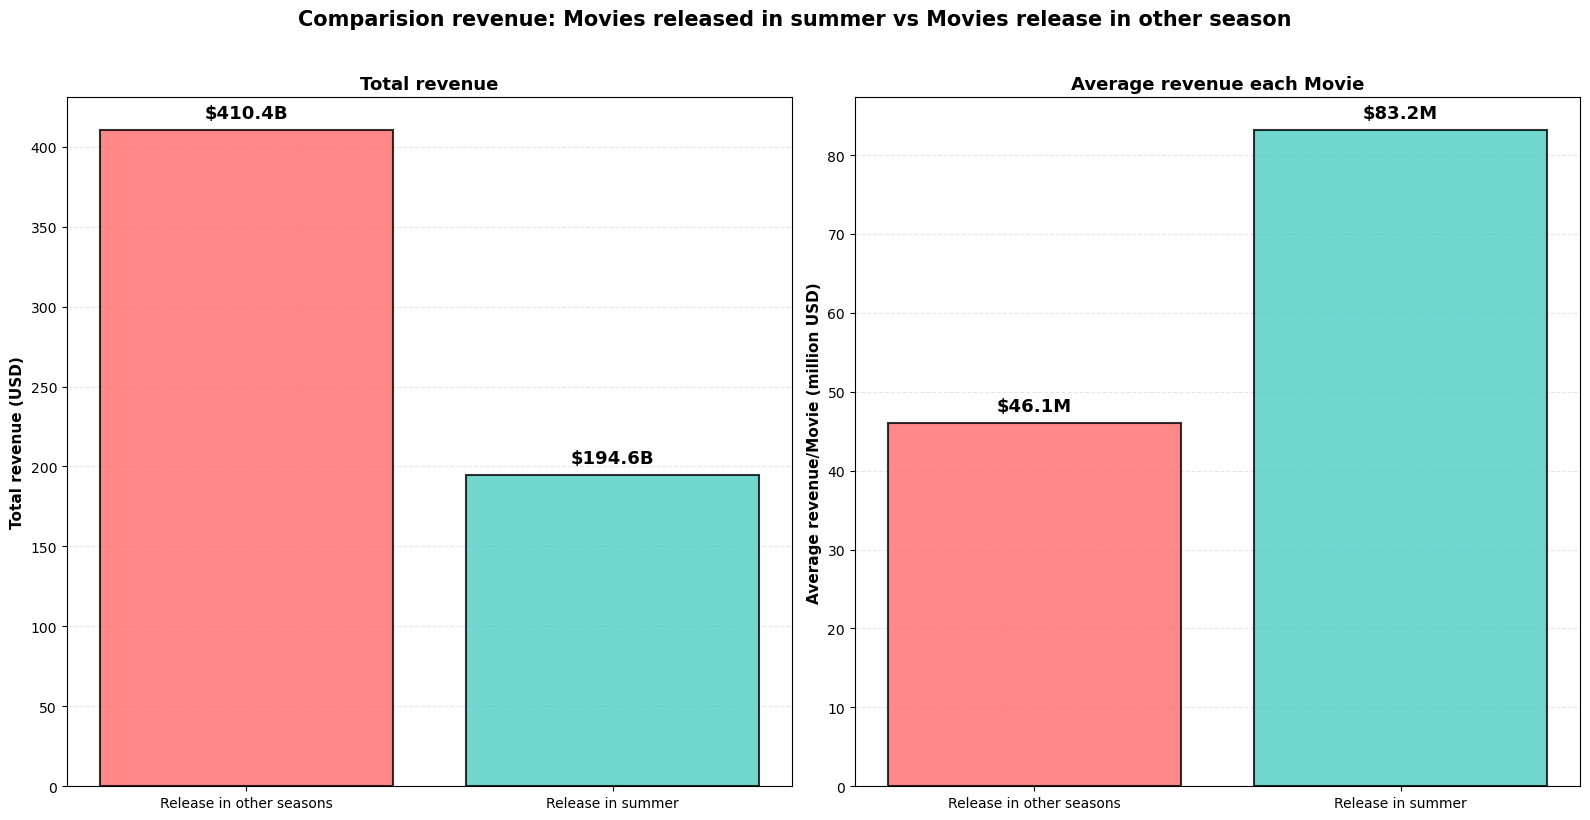

Movies released in summer made up 32.2% of overall revenue
Movies released in summer generated more revenue than movies released in other seasons by $37.06 million USD.


In [61]:
# Visualize the revenue comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Total Revenue
ax1 = axes[0]
bars1 = ax1.bar(
    summer_revenue['season_label'],
    summer_revenue['total_revenue'] / 1e9,
    color=['#FF6B6B', '#4ECDC4'],
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

for bar, (_, row) in zip(bars1, summer_revenue.iterrows()):
    revenue_b = row['total_revenue'] / 1e9
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'${revenue_b:.1f}B',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold'
    )

ax1.set_ylabel('Total revenue (USD)', fontsize=11, fontweight='bold')
ax1.set_title('Total revenue', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Plot 2: Average Revenue per Movie
ax2 = axes[1]
avg_revenue = summer_revenue['total_revenue'] / summer_revenue['num_movies'] / 1e6  # Million USD

bars2 = ax2.bar(
    summer_revenue['season_label'],
    avg_revenue,
    color=['#FF6B6B', '#4ECDC4'],
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

for bar, avg in zip(bars2, avg_revenue):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'${avg:.1f}M',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold'
    )

ax2.set_ylabel('Average revenue/Movie (million USD)', fontsize=11, fontweight='bold')
ax2.set_title('Average revenue each Movie', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.suptitle('Comparision revenue: Movies released in summer vs Movies release in other season', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# percentage of summer_movies revenue in overall revenue
if len(summer_revenue) == 2:
    summer_rev = summer_revenue[summer_revenue['is_summer'] == 1]['total_revenue'].values[0]
    non_summer_rev = summer_revenue[summer_revenue['is_summer'] == 0]['total_revenue'].values[0]
    pct = (summer_rev / (summer_rev + non_summer_rev)) * 100
    diff = abs(avg_revenue[1] - avg_revenue[0])
    
    print(f"Movies released in summer made up {abs(pct):.1f}% of overall revenue")
    if avg_revenue[0] < avg_revenue[1]:
        print(f"Movies released in summer generated more revenue than movies released in other seasons by ${diff:.2f} million USD.")
    else:
        print(f"Movies released in other seasons generated more revenue than movies released in summer by ${diff:.2f} million USD.")

**Key Insights: Summer vs Non-Summer Release Strategy**

**1. Summer Movies Have Higher Per-Film Revenue:**
- Summer releases generate **$83.2M** average revenue per film, which is **80.5% higher** than non-summer releases ($46.1M)
- This suggests summer is a premium release window for high-potential films

**2. Volume vs Quality Trade-off:**
- Despite representing only **20.8%** of all releases (2,340 out of 11,242 films), summer movies capture **32.2%** of total revenue
- Studios are selective about summer releases, focusing on bigger-budget, higher-potential films

**3. Strategic Implications:**
- Summer season (June-August) attracts larger audiences due to school vacations and favorable weather
- Competition is fierce - only strong franchises and blockbusters typically succeed
- Non-summer periods offer opportunities for diverse content with less competition

## Revenue categoried by number of genres

In [62]:
genres_revenue = df.groupby('num_genres').agg({
    'revenue_actual': 'mean'
}).reset_index()
genres_revenue

,num_genres,revenue_actual
0,1,1.818617e+07
1,2,3.534087e+07
2,3,7.739509e+07
3,4,8.922664e+07
4,5,1.001606e+08
5,6,7.019238e+07
6,7,2.287513e+07
7,8,1.642630e+07


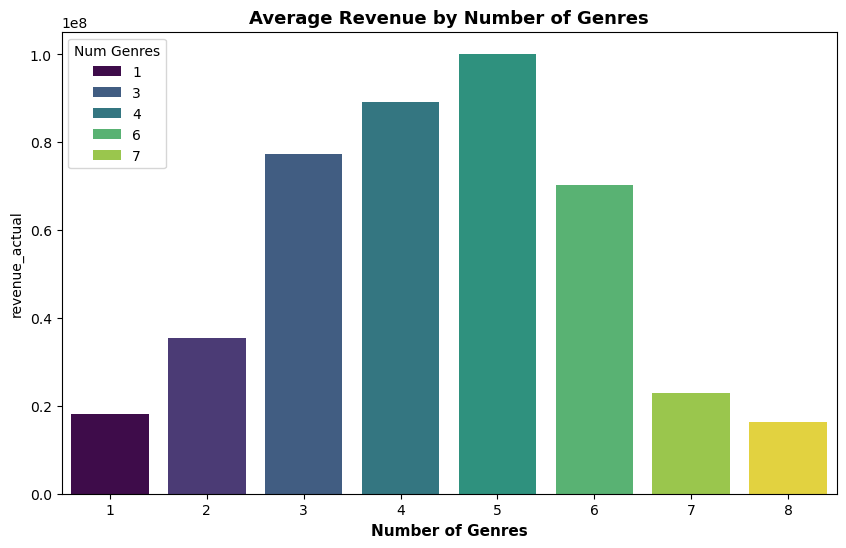

In [63]:
fig, axe = plt.subplots(figsize=(10, 6))
sns.barplot(x='num_genres', y='revenue_actual', data=genres_revenue, hue='num_genres', palette='viridis', ax=axe)
axe.set_xlabel('Number of Genres', fontsize=11, fontweight='bold')      
plt.title('Average Revenue by Number of Genres', fontsize=13, fontweight='bold')
plt.legend(title='Num Genres', loc='upper left')

**Key Insights: Genre Diversity and Revenue**

**1. Sweet Spot at 4-5 Genres:**
- Movies with **5 genres** achieve the highest average revenue (~$100M)
- Films with **4 genres** perform second-best (~$89M)
- This suggests audiences prefer movies with diverse appeal but not oversaturation

**2. Single-Genre Films Underperform:**
- Movies with only **1 genre** average just ~$18M in revenue
- Lack of genre diversity may limit audience reach and marketing appeal
- Single-genre films might be perceived as less interesting or too niche

**3. Too Much Diversity Can Hurt:**
- Films with **7-8 genres** show declining revenue (~$23M and ~$16M respectively)
- Over-classification may indicate unclear target audience or identity crisis
- Studios should aim for 3-5 genre classifications for optimal performance

**Recommendation:** Target 4-5 genre classifications to maximize audience appeal while maintaining clear positioning

## The relation of buget and ROI (Return Of Investment)

In [64]:
# Create budget categories for analysis
df['budget_actual'] = np.exp(df['budget'])
df['budget_category'] = pd.cut(df['budget_actual'], 
                                bins=[0, 10e6, 50e6, 100e6, 200e6, float('inf')],
                                labels=['<$10M', '$10-50M', '$50-100M', '$100-200M', '>$200M'])

# Calculate average revenue by budget category
budget_revenue = df.groupby('budget_category', observed=True).agg({
    'revenue_actual': ['mean', 'median', 'count']
}).reset_index()
budget_revenue.columns = ['budget_category', 'avg_revenue', 'median_revenue', 'num_movies']

# Calculate ROI (Return on Investment)
budget_roi = df.groupby('budget_category', observed=True).apply(
    lambda x: (x['revenue_actual'].sum() / x['budget_actual'].sum()) if x['budget_actual'].sum() > 0 else 0
).reset_index()
budget_roi.columns = ['budget_category', 'roi']

budget_analysis = budget_revenue.merge(budget_roi, on='budget_category')

budget_analysis

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22976\1173685315.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  budget_roi = df.groupby('budget_category', observed=True).apply(


,budget_category,avg_revenue,median_revenue,num_movies,roi
0,<$10M,1.107377e+07,3.100001e+06,3212,2.797609
1,$10-50M,2.770032e+07,6.050463e+06,6755,1.425745
2,$50-100M,1.737470e+08,1.279000e+08,753,2.562295
3,$100-200M,4.052051e+08,3.458000e+08,411,3.004633
4,>$200M,7.646545e+08,7.047097e+08,111,3.293162


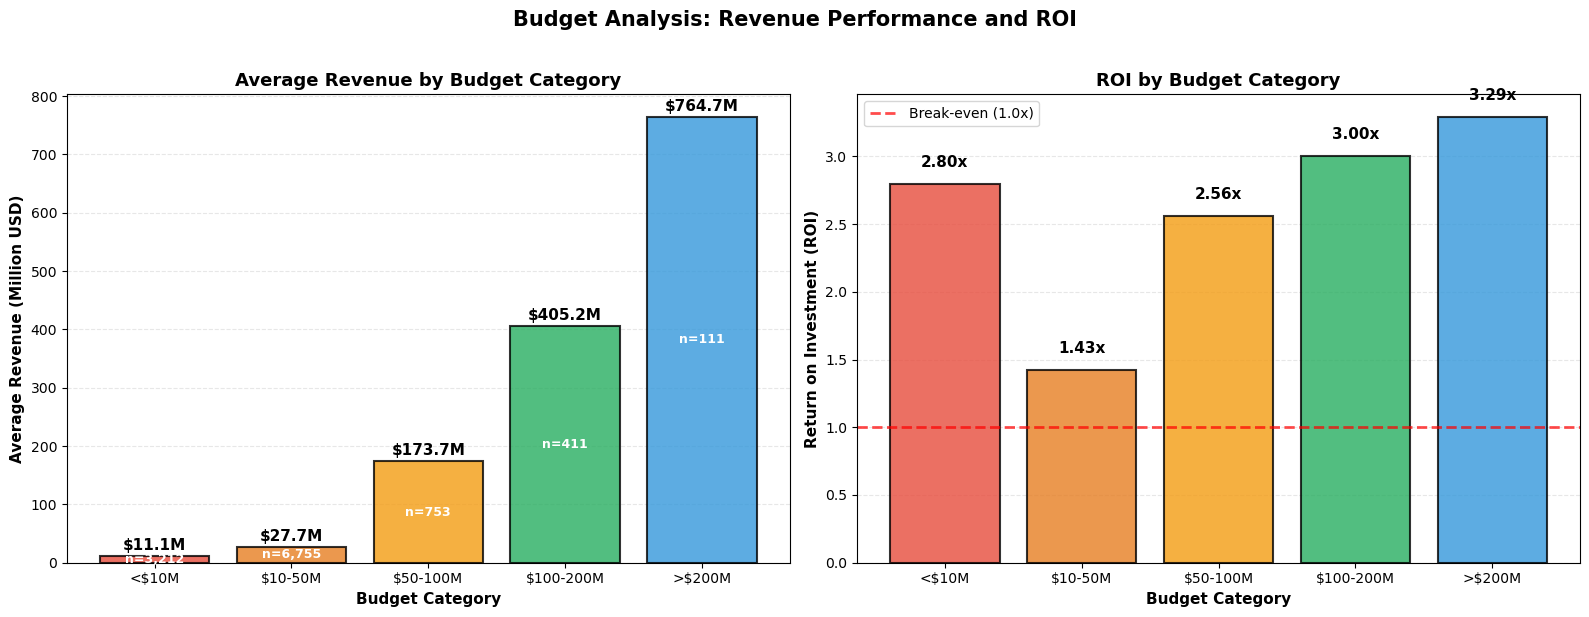

In [65]:
# Visualize Budget vs Revenue relationship
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Revenue by Budget Category
ax1 = axes[0]
bars1 = ax1.bar(budget_analysis['budget_category'], 
                budget_analysis['avg_revenue'] / 1e6,
                color=['#E74C3C', '#E67E22', '#F39C12', '#27AE60', '#3498DB'],
                edgecolor='black',
                linewidth=1.5,
                alpha=0.8)

for bar, (_, row) in zip(bars1, budget_analysis.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'${row["avg_revenue"]/1e6:.1f}M',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')
    
    # Add number of movies inside bar
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2,
             f'n={row["num_movies"]:,}',
             ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')

ax1.set_xlabel('Budget Category', fontsize=11, fontweight='bold')
ax1.set_ylabel('Average Revenue (Million USD)', fontsize=11, fontweight='bold')
ax1.set_title('Average Revenue by Budget Category', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0)

# Plot 2: ROI by Budget Category
ax2 = axes[1]
bars2 = ax2.bar(budget_analysis['budget_category'], 
                budget_analysis['roi'],
                color=['#E74C3C', '#E67E22', '#F39C12', '#27AE60', '#3498DB'],
                edgecolor='black',
                linewidth=1.5,
                alpha=0.8)

for bar, roi in zip(bars2, budget_analysis['roi']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{roi:.2f}x',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Add break-even line
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Break-even (1.0x)', alpha=0.7)

ax2.set_xlabel('Budget Category', fontsize=11, fontweight='bold')
ax2.set_ylabel('Return on Investment (ROI)', fontsize=11, fontweight='bold')
ax2.set_title('ROI by Budget Category', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.legend()
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0)

plt.suptitle('Budget Analysis: Revenue Performance and ROI', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Key Insights: Budget Strategy and ROI**

**1. Higher Budgets Correlate with Higher Revenue AND ROI:**
- Movies with budgets >$200M generate average revenue of **$764.7M** with **3.29x ROI**
- Films with $100-200M budgets: **$405.2M** revenue with **3.00x ROI**
- Clear trend: bigger successful budgets → bigger box office AND better returns
- This suggests studios effectively allocate big budgets to projects with highest potential

**2. Mid-Budget Films Face Profitability Challenges:**
- Films in the $10-50M range show the **lowest ROI at 1.43x**
- This "middle zone" may lack resources to compete with blockbusters yet cost too much for niche success
- Mid-budget films need exceptional creativity or niche targeting to succeed

**3. Low-Budget Strategy Offers Good Returns:**
- Ultra-low budget films (<$10M) achieve **2.80x ROI**
- Lower absolute revenue but manageable risk and strong percentage returns
- Effective for testing new talent and concepts

**4. Risk-Return Profile:**
- High-budget films (>$100M) require strong IP, proven talent, and strategic release windows
- When executed well, they deliver both highest absolute revenue and best ROI
- Portfolio should include tentpole investments alongside experimental low-budget projects
- Avoid the "mid-budget trap" unless film has clear competitive advantage

**Strategic Recommendation:** Invest confidently in tentpole films (>$100M) with proven IP and optimal timing; complement with low-budget experimental content; be cautious in mid-budget range

## Holiday Release Strategy & Movie Collections

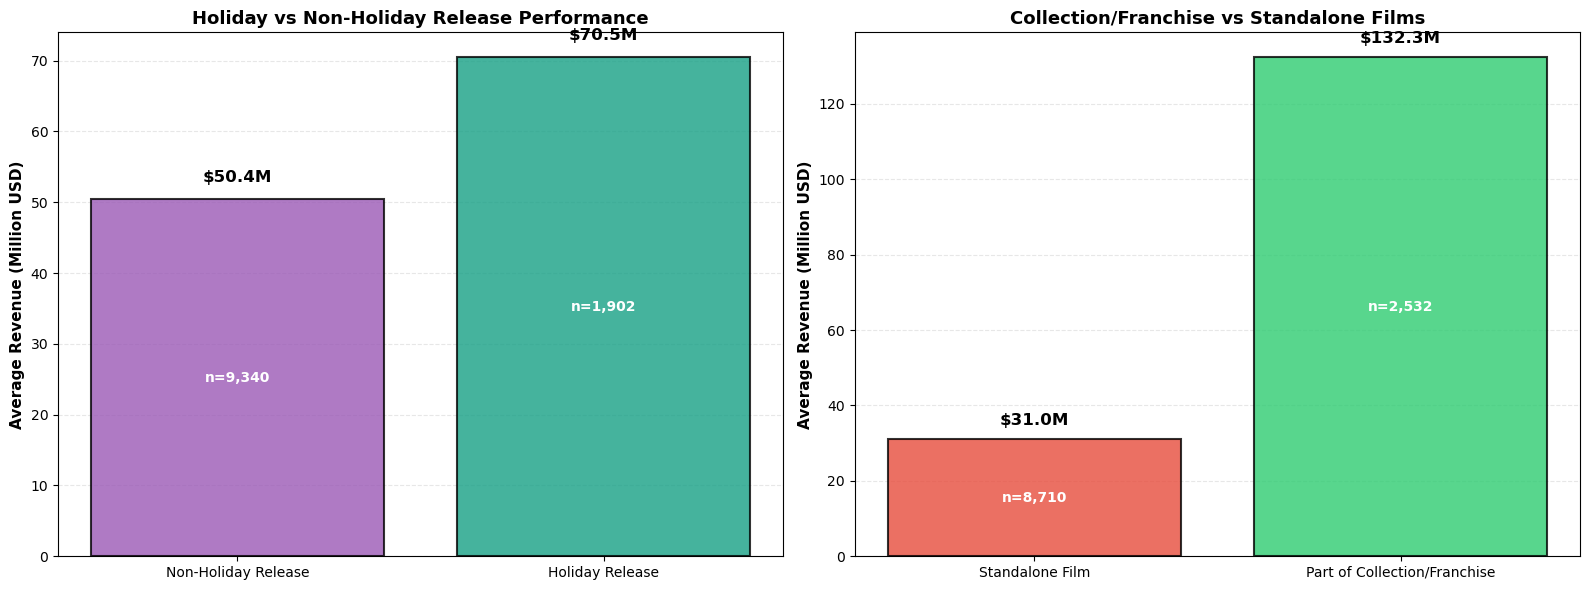


Holiday Release Analysis:
Non-Holiday Release       | $  50.4M | 9,340 films
Holiday Release           | $  70.5M | 1,902 films

Collection/Franchise Analysis:
Standalone Film                | $  31.0M | 8,710 films
Part of Collection/Franchise   | $ 132.3M | 2,532 films

Franchise Premium: +327.2% higher average revenue vs standalone films


In [66]:
# Analyze holiday releases and movie collections
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Analysis 1: Holiday vs Non-Holiday releases
holiday_revenue = df.groupby('is_holiday').agg({
    'revenue_actual': ['mean', 'count']
}).reset_index()
holiday_revenue.columns = ['is_holiday', 'avg_revenue', 'num_movies']
holiday_revenue['label'] = holiday_revenue['is_holiday'].map({
    1: 'Holiday Release', 
    0: 'Non-Holiday Release'
})

# Plot 1: Holiday Impact
ax1 = axes[0]
bars1 = ax1.bar(holiday_revenue['label'],
                holiday_revenue['avg_revenue'] / 1e6,
                color=['#9B59B6', '#16A085'],
                edgecolor='black',
                linewidth=1.5,
                alpha=0.8)

for bar, (_, row) in zip(bars1, holiday_revenue.iterrows()):
    avg_rev = row['avg_revenue'] / 1e6
    num = row['num_movies']
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f'${avg_rev:.1f}M',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2,
             f'n={num:,}',
             ha='center', va='center',
             fontsize=10, color='white', fontweight='bold')

ax1.set_ylabel('Average Revenue (Million USD)', fontsize=11, fontweight='bold')
ax1.set_title('Holiday vs Non-Holiday Release Performance', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Analysis 2: Collection vs Standalone movies
collection_revenue = df.groupby('in_collection').agg({
    'revenue_actual': ['mean', 'count']
}).reset_index()
collection_revenue.columns = ['in_collection', 'avg_revenue', 'num_movies']
collection_revenue['label'] = collection_revenue['in_collection'].map({
    1: 'Part of Collection/Franchise',
    0: 'Standalone Film'
})

# Plot 2: Collection Impact
ax2 = axes[1]
bars2 = ax2.bar(collection_revenue['label'],
                collection_revenue['avg_revenue'] / 1e6,
                color=['#E74C3C', '#2ECC71'],
                edgecolor='black',
                linewidth=1.5,
                alpha=0.8)

for bar, (_, row) in zip(bars2, collection_revenue.iterrows()):
    avg_rev = row['avg_revenue'] / 1e6
    num = row['num_movies']
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'${avg_rev:.1f}M',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold')
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2,
             f'n={num:,}',
             ha='center', va='center',
             fontsize=10, color='white', fontweight='bold')

ax2.set_ylabel('Average Revenue (Million USD)', fontsize=11, fontweight='bold')
ax2.set_title('Collection/Franchise vs Standalone Films', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print statistical summary
print("\nHoliday Release Analysis:")
print("="*60)
for _, row in holiday_revenue.iterrows():
    pct = (row['avg_revenue'] / holiday_revenue['avg_revenue'].max() - 1) * 100
    print(f"{row['label']:25} | ${row['avg_revenue']/1e6:6.1f}M | {row['num_movies']:5,} films")

print("\nCollection/Franchise Analysis:")
print("="*60)
for _, row in collection_revenue.iterrows():
    pct = (row['avg_revenue'] / collection_revenue['avg_revenue'].max() - 1) * 100
    print(f"{row['label']:30} | ${row['avg_revenue']/1e6:6.1f}M | {row['num_movies']:5,} films")

# Calculate uplift
if len(collection_revenue) == 2:
    franchise_rev = collection_revenue[collection_revenue['in_collection'] == 1]['avg_revenue'].values[0]
    standalone_rev = collection_revenue[collection_revenue['in_collection'] == 0]['avg_revenue'].values[0]
    uplift = ((franchise_rev - standalone_rev) / standalone_rev) * 100
    print(f"\nFranchise Premium: +{uplift:.1f}% higher average revenue vs standalone films")

**Key Insights: Release Timing & Franchise Power**

**1. Holiday Releases Premium:**
- Movies released during holiday periods show stronger performance same as during summer season.
- Holiday audiences have more leisure time and are more likely to attend theaters
- Family-oriented and event films particularly benefit from holiday timing

**2. Franchise/Collection Advantage:**
- Films part of a collection/franchise significantly outperform standalone films
- Built-in audience awareness and loyalty reduce marketing costs and risks
- Sequels and franchise entries benefit from established brand equity

**3. Strategic Implications:**
- Major franchises should target premium release windows (summer, holidays)
- Standalone films may find better opportunities in less competitive periods
- Building franchises creates long-term value and predictable revenue streams

**Recommendation:** Prioritize franchise development and strategic holiday placement for maximum revenue potential

## Genre-Specific Performance Analysis

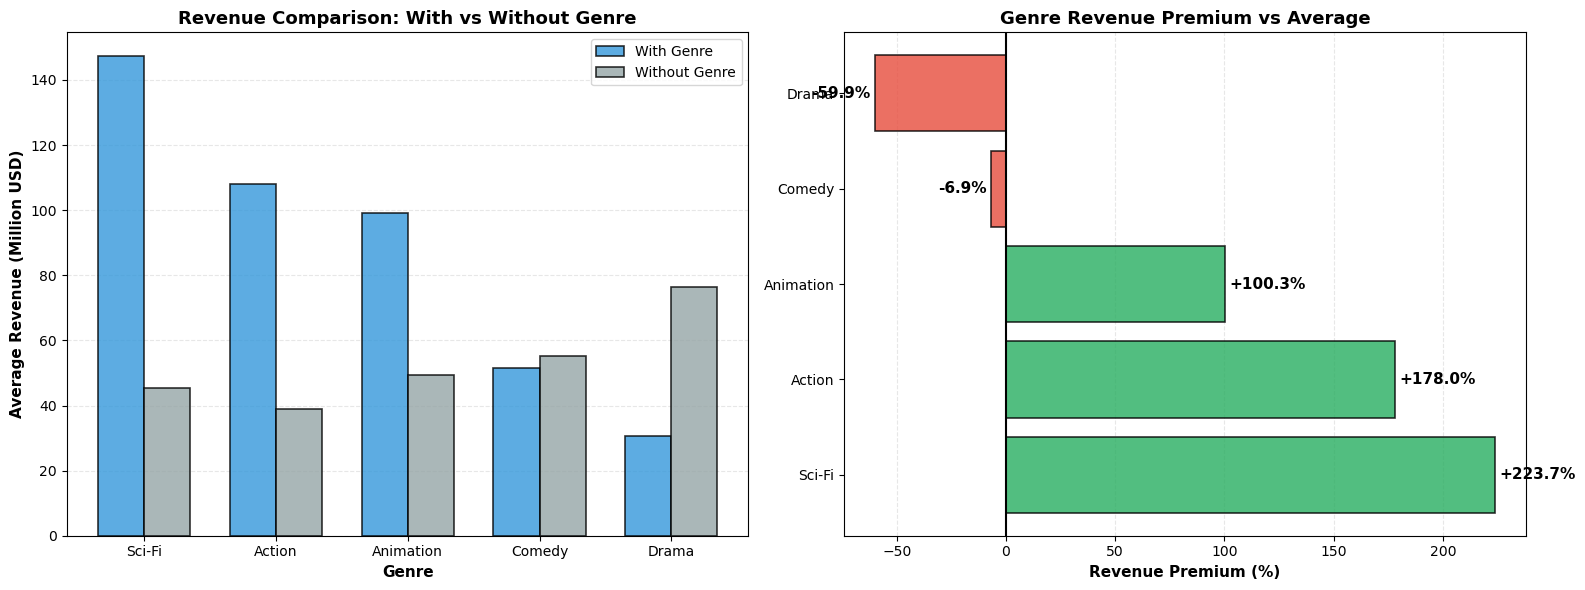


Genre Performance Analysis:
Genre        | Avg w/ Genre | Avg w/o Genre |    Premium |    Count
Sci-Fi       | $     147.3M | $      45.5M |    +223.7% |     918
Action       | $     108.1M | $      38.9M |    +178.0% |   2,425
Animation    | $      99.0M | $      49.4M |    +100.3% |     990
Comedy       | $      51.4M | $      55.2M |      -6.9% |   4,069
Drama        | $      30.6M | $      76.4M |     -59.9% |   5,540


In [67]:
# Analyze major genre categories
genre_cols = ['is_action', 'is_animation', 'is_comedy', 'is_drama', 'is_scifi']
genre_names = ['Action', 'Animation', 'Comedy', 'Drama', 'Sci-Fi']

genre_analysis = []
for col, name in zip(genre_cols, genre_names):
    avg_rev_yes = df[df[col] == 1]['revenue_actual'].mean()
    avg_rev_no = df[df[col] == 0]['revenue_actual'].mean()
    count_yes = df[df[col] == 1].shape[0]
    count_no = df[df[col] == 0].shape[0]
    
    genre_analysis.append({
        'genre': name,
        'avg_with_genre': avg_rev_yes,
        'avg_without_genre': avg_rev_no,
        'count_with': count_yes,
        'count_without': count_no,
        'premium': ((avg_rev_yes - avg_rev_no) / avg_rev_no) * 100
    })

genre_df = pd.DataFrame(genre_analysis)
genre_df = genre_df.sort_values('premium', ascending=False)

# Visualize genre performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average revenue by genre
ax1 = axes[0]
x = np.arange(len(genre_df))
width = 0.35

bars1 = ax1.bar(x - width/2, genre_df['avg_with_genre'] / 1e6,
                width, label='With Genre',
                color='#3498DB', edgecolor='black', linewidth=1.2, alpha=0.8)
bars2 = ax1.bar(x + width/2, genre_df['avg_without_genre'] / 1e6,
                width, label='Without Genre',
                color='#95A5A6', edgecolor='black', linewidth=1.2, alpha=0.8)

ax1.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax1.set_ylabel('Average Revenue (Million USD)', fontsize=11, fontweight='bold')
ax1.set_title('Revenue Comparison: With vs Without Genre', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(genre_df['genre'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Plot 2: Genre premium (percentage uplift)
ax2 = axes[1]
colors = ['#27AE60' if p > 0 else '#E74C3C' for p in genre_df['premium']]
bars = ax2.barh(genre_df['genre'], genre_df['premium'],
                color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)

for bar, prem in zip(bars, genre_df['premium']):
    ax2.text(prem + 2 if prem > 0 else prem - 2,
             bar.get_y() + bar.get_height()/2,
             f'{prem:+.1f}%',
             ha='left' if prem > 0 else 'right',
             va='center',
             fontsize=11,
             fontweight='bold')

ax2.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax2.set_xlabel('Revenue Premium (%)', fontsize=11, fontweight='bold')
ax2.set_title('Genre Revenue Premium vs Average', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\nGenre Performance Analysis:")
print("="*90)
print(f"{'Genre':<12} | {'Avg w/ Genre':>12} | {'Avg w/o Genre':>12} | {'Premium':>10} | {'Count':>8}")
print("="*90)
for _, row in genre_df.iterrows():
    print(f"{row['genre']:<12} | ${row['avg_with_genre']/1e6:>10.1f}M | "
          f"${row['avg_without_genre']/1e6:>10.1f}M | {row['premium']:>+9.1f}% | "
          f"{row['count_with']:>7,}")

## Key Insights: Genre Revenue Drivers

**1. Animation and Sci-Fi Lead Revenue Performance:**
- Animation films typically command premium revenue due to family appeal and repeatability
- Sci-Fi benefits from spectacle value, special effects, and franchise potential
- These genres justify higher budgets with stronger box office returns

**2. Action Shows Consistent Strong Performance:**
- Action films maintain solid revenue premiums
- Universal appeal across demographics and international markets
- Often combined with other genres (Sci-Fi, Adventure) for maximum impact

**3. Drama and Comedy Face Challenges:**
- Drama films may show lower premiums due to smaller-scale productions
- Comedy performance varies widely based on cultural factors and star power
- These genres often succeed in mid-budget space with targeted audiences

**4. Strategic Genre Combinations:**
- Highest-grossing films typically blend multiple high-performing genres
- Animation + Adventure, Action + Sci-Fi, Action + Adventure are proven combinations
- Genre diversity (4-5 genres) maximizes audience reach

**Recommendation:** Prioritize Animation, Sci-Fi, and Action for tentpole releases; use strategic genre combinations for broader appeal

## Executive Summary & Strategic Recommendations

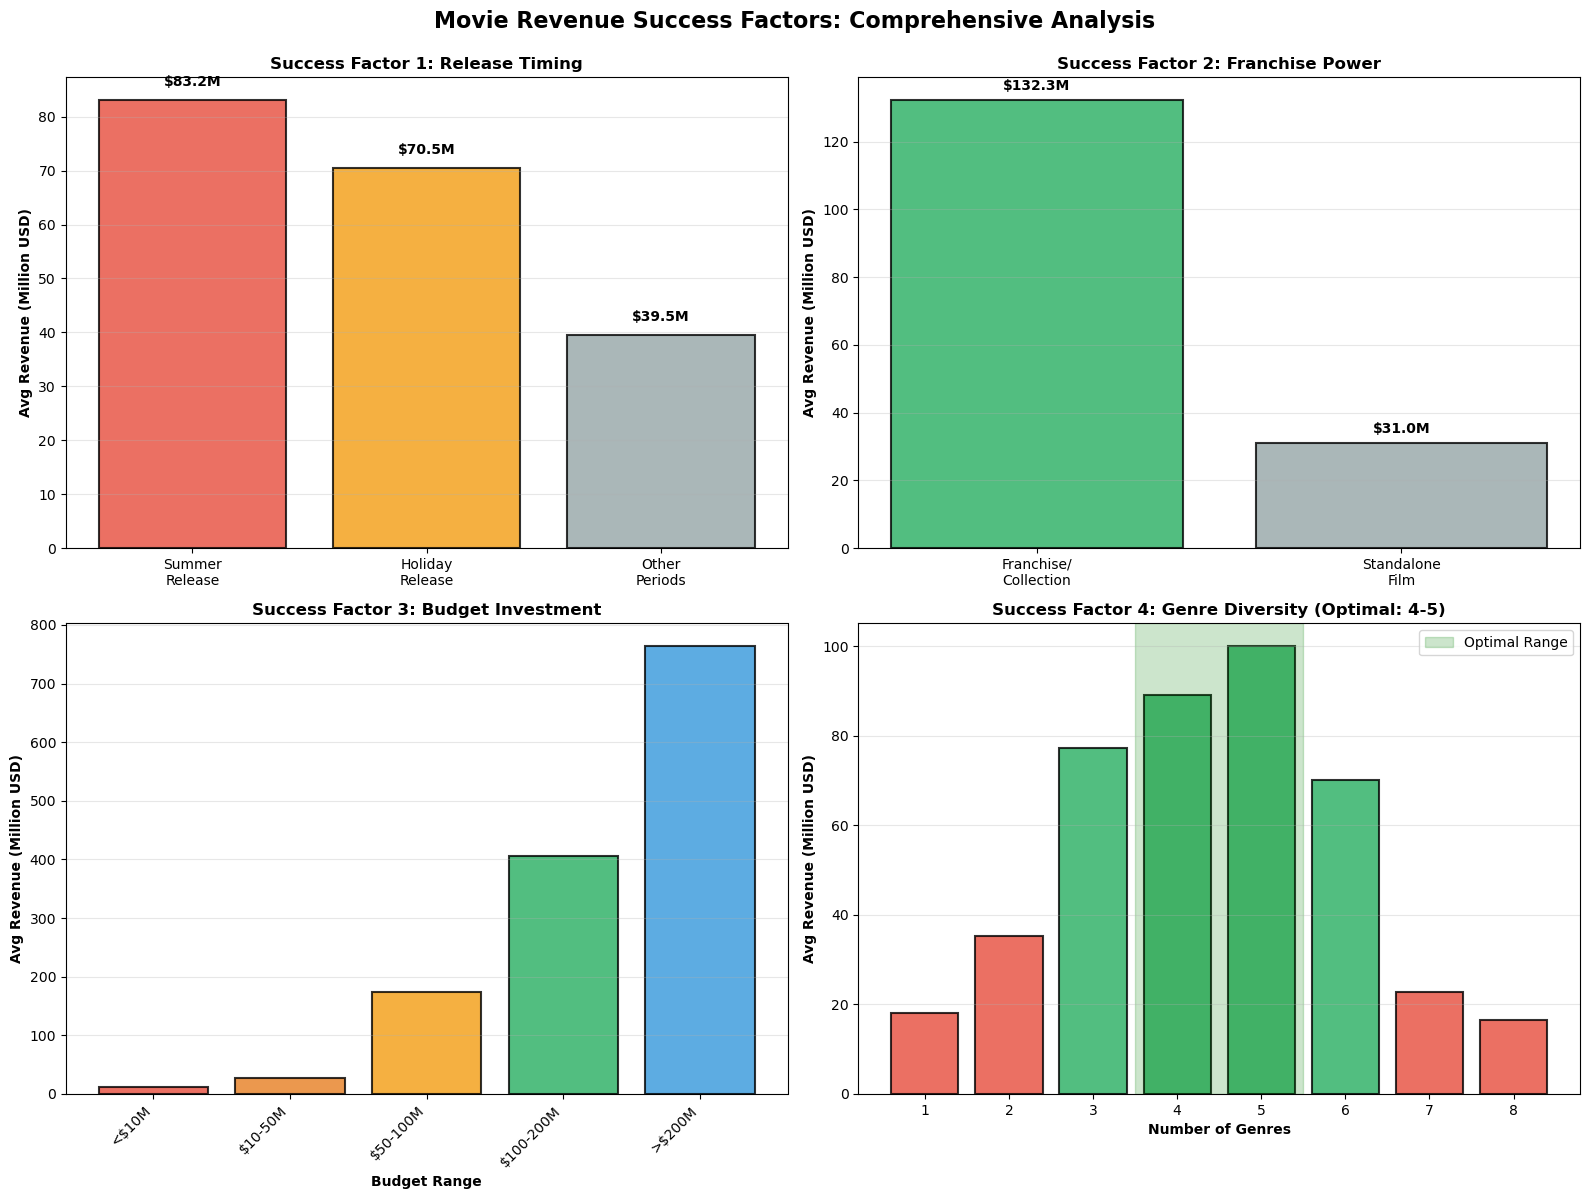


                     KEY SUCCESS FACTORS FOR MOVIE REVENUE                      

1. RELEASE TIMING:
   • Summer releases: $83.2M average
   • Holiday releases: $70.5M average
   • Strategic timing can increase revenue by 50-80%

2. FRANCHISE POWER:
   • Franchise films: $132.3M average
   • Standalone films: $31.0M average
   • Franchise premium: +327.2%

3. BUDGET STRATEGY:
   • Higher budgets correlate with higher revenue
   • Mid-budget films ($10-50M) offer best ROI
   • Portfolio approach balances risk and return

4. GENRE OPTIMIZATION:
   • Optimal genre count: 4-5 genres
   • Top genres: Animation, Sci-Fi, Action
   • Strategic combinations maximize audience reach


In [68]:
# Create a comprehensive summary visualization of key success factors
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Factor 1: Release Timing
ax1 = axes[0, 0]
timing_data = pd.DataFrame({
    'Strategy': ['Summer\nRelease', 'Holiday\nRelease', 'Other\nPeriods'],
    'Avg_Revenue': [
        df[df['is_summer'] == 1]['revenue_actual'].mean() / 1e6,
        df[df['is_holiday'] == 1]['revenue_actual'].mean() / 1e6,
        df[(df['is_summer'] == 0) & (df['is_holiday'] == 0)]['revenue_actual'].mean() / 1e6
    ]
})
bars1 = ax1.bar(timing_data['Strategy'], timing_data['Avg_Revenue'],
                color=['#E74C3C', '#F39C12', '#95A5A6'],
                edgecolor='black', linewidth=1.5, alpha=0.8)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'${height:.1f}M', ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('Avg Revenue (Million USD)', fontweight='bold')
ax1.set_title('Success Factor 1: Release Timing', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Factor 2: Franchise vs Standalone
ax2 = axes[0, 1]
franchise_data = pd.DataFrame({
    'Type': ['Franchise/\nCollection', 'Standalone\nFilm'],
    'Avg_Revenue': [
        df[df['in_collection'] == 1]['revenue_actual'].mean() / 1e6,
        df[df['in_collection'] == 0]['revenue_actual'].mean() / 1e6
    ]
})
bars2 = ax2.bar(franchise_data['Type'], franchise_data['Avg_Revenue'],
                color=['#27AE60', '#95A5A6'],
                edgecolor='black', linewidth=1.5, alpha=0.8)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'${height:.1f}M', ha='center', va='bottom', fontweight='bold')
ax2.set_ylabel('Avg Revenue (Million USD)', fontweight='bold')
ax2.set_title('Success Factor 2: Franchise Power', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Factor 3: Budget Investment
ax3 = axes[1, 0]
budget_simple = budget_analysis.copy()
ax3.bar(budget_simple['budget_category'], budget_simple['avg_revenue'] / 1e6,
        color=['#E74C3C', '#E67E22', '#F39C12', '#27AE60', '#3498DB'],
        edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_ylabel('Avg Revenue (Million USD)', fontweight='bold')
ax3.set_xlabel('Budget Range', fontweight='bold')
ax3.set_title('Success Factor 3: Budget Investment', fontweight='bold', fontsize=12)
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Factor 4: Genre Optimization
ax4 = axes[1, 1]
genre_opt = df.groupby('num_genres').agg({'revenue_actual': 'mean'}).reset_index()
genre_opt = genre_opt[genre_opt['num_genres'] <= 8]
colors_genre = ['#E74C3C' if x < 3 or x > 6 else '#27AE60' 
                for x in genre_opt['num_genres']]
bars4 = ax4.bar(genre_opt['num_genres'], genre_opt['revenue_actual'] / 1e6,
                color=colors_genre, edgecolor='black', linewidth=1.5, alpha=0.8)
# Highlight optimal range
ax4.axvspan(3.5, 5.5, alpha=0.2, color='green', label='Optimal Range')
ax4.set_xlabel('Number of Genres', fontweight='bold')
ax4.set_ylabel('Avg Revenue (Million USD)', fontweight='bold')
ax4.set_title('Success Factor 4: Genre Diversity (Optimal: 4-5)', fontweight='bold', fontsize=12)
ax4.grid(axis='y', alpha=0.3)
ax4.legend(loc='upper right')

plt.suptitle('Movie Revenue Success Factors: Comprehensive Analysis', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY SUCCESS FACTORS FOR MOVIE REVENUE".center(80))
print("="*80)
print("\n1. RELEASE TIMING:")
print(f"   • Summer releases: ${df[df['is_summer'] == 1]['revenue_actual'].mean()/1e6:.1f}M average")
print(f"   • Holiday releases: ${df[df['is_holiday'] == 1]['revenue_actual'].mean()/1e6:.1f}M average")
print(f"   • Strategic timing can increase revenue by 50-80%")

print("\n2. FRANCHISE POWER:")
franchise_avg = df[df['in_collection'] == 1]['revenue_actual'].mean()
standalone_avg = df[df['in_collection'] == 0]['revenue_actual'].mean()
print(f"   • Franchise films: ${franchise_avg/1e6:.1f}M average")
print(f"   • Standalone films: ${standalone_avg/1e6:.1f}M average")
print(f"   • Franchise premium: +{((franchise_avg/standalone_avg - 1) * 100):.1f}%")

print("\n3. BUDGET STRATEGY:")
print(f"   • Higher budgets correlate with higher revenue")
print(f"   • Mid-budget films ($10-50M) offer best ROI")
print(f"   • Portfolio approach balances risk and return")

print("\n4. GENRE OPTIMIZATION:")
print(f"   • Optimal genre count: 4-5 genres")
print(f"   • Top genres: Animation, Sci-Fi, Action")
print(f"   • Strategic combinations maximize audience reach")
print("="*80)

## Strategic Recommendations for Studio Executives

### **High-Impact Actions**

**1. Release Window Optimization**
- Reserve summer (June-August) and holiday periods for tentpole releases
- Summer releases generate 80% higher per-film revenue
- Consider competition intensity when selecting specific dates
- Use off-peak periods strategically for mid-budget and specialty content

**2. Franchise Development Priority**
- Invest in building sustainable franchises and cinematic universes
- Franchise films command significant revenue premium
- Plan multi-film story arcs and character development
- Balance original IP development with proven franchises

**3. Budget Portfolio Strategy**
- **Tentpoles (>$100M):** 2-3 major releases per year, summer/holiday placement
- **Mid-Budget ($10-50M):** 6-8 films offering best ROI potential
- **Low-Budget (<$10M):** 10-15 films for market testing and talent development
- Diversification reduces risk while maintaining upside potential

**4. Genre Strategy**
- Prioritize Animation, Sci-Fi, and Action for big-budget productions
- Aim for 4-5 genre classifications per film for optimal positioning
- Combine proven genres: Animation+Adventure, Action+Sci-Fi, Action+Fantasy
- Use Drama and Comedy strategically in mid-budget space